# Comparison and Testing of BaselineGAT with Custom MPNN
## Loading and split dataset for BaselineGNNs

In [1]:
from atoMLtype.GNN.GNNmodel import GNNTrainer, BaselineGCN, BaselineGAT
from atoMLtype.GNN.GNNdataset import GNNdataset
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_heatmap, \
    plot_category_heatmap, plot_detailed_cross_category_heatmap
from torch.utils.data import random_split
import numpy as np

[15:32:35] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[15:32:35] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[15:32:35] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[15:32:35] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

num_node_features = 152
num_y_ATs = 75
FULL DATASET:


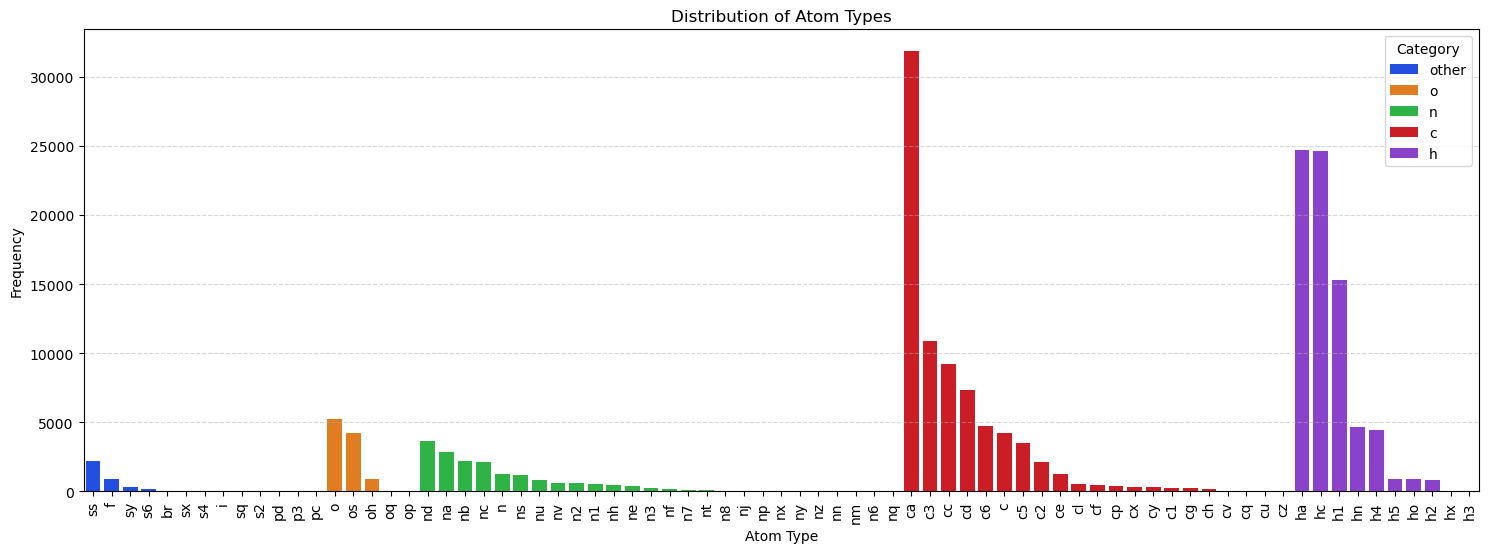

,Atom Type,Count,Category
0,ss,2200,other
1,f,881,other
2,sy,304,other
3,s6,147,other
4,br,68,other
...,...,...,...
70,h5,933,h
71,ho,879,h
72,h2,819,h
73,hx,31,h


In [2]:
# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))

print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(gnn_test_dataset))
test_size = len(gnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(gnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(gnn_test_dataset.all_labels))

## Testing BaselineGCN - 2 layer conv nn on atom features only with relu activation functions

BaselineGCN - Number of parameters: 379467


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.7668 | Val Loss: 0.7726
Epoch - 20: Train Loss: 0.6772 | Val Loss: 0.6988
Epoch - 30: Train Loss: 0.6360 | Val Loss: 0.6594


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.6152 | Val Loss: 0.6276
Epoch - 20: Train Loss: 0.5963 | Val Loss: 0.6137
Epoch - 30: Train Loss: 0.5822 | Val Loss: 0.6048


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.5779 | Val Loss: 0.5857
Epoch - 20: Train Loss: 0.5671 | Val Loss: 0.5764
Epoch - 30: Train Loss: 0.5626 | Val Loss: 0.5793


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.5544 | Val Loss: 0.5754
Epoch - 20: Train Loss: 0.5485 | Val Loss: 0.5768
Epoch - 30: Train Loss: 0.5415 | Val Loss: 0.5810


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.5446 | Val Loss: 0.5425
Epoch - 20: Train Loss: 0.5402 | Val Loss: 0.5498
Epoch - 30: Train Loss: 0.5340 | Val Loss: 0.5504


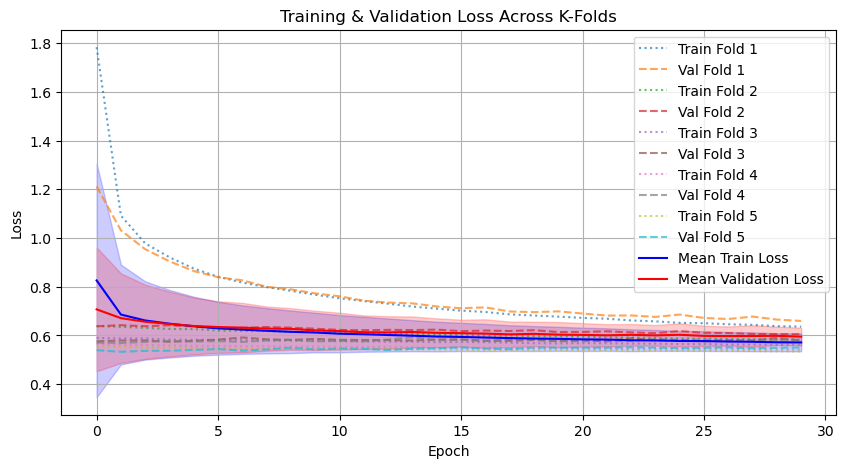

Evaluation Metrics: {'Accuracy': 0.7737218486498025, 'F1-score': 0.7536066585776316}


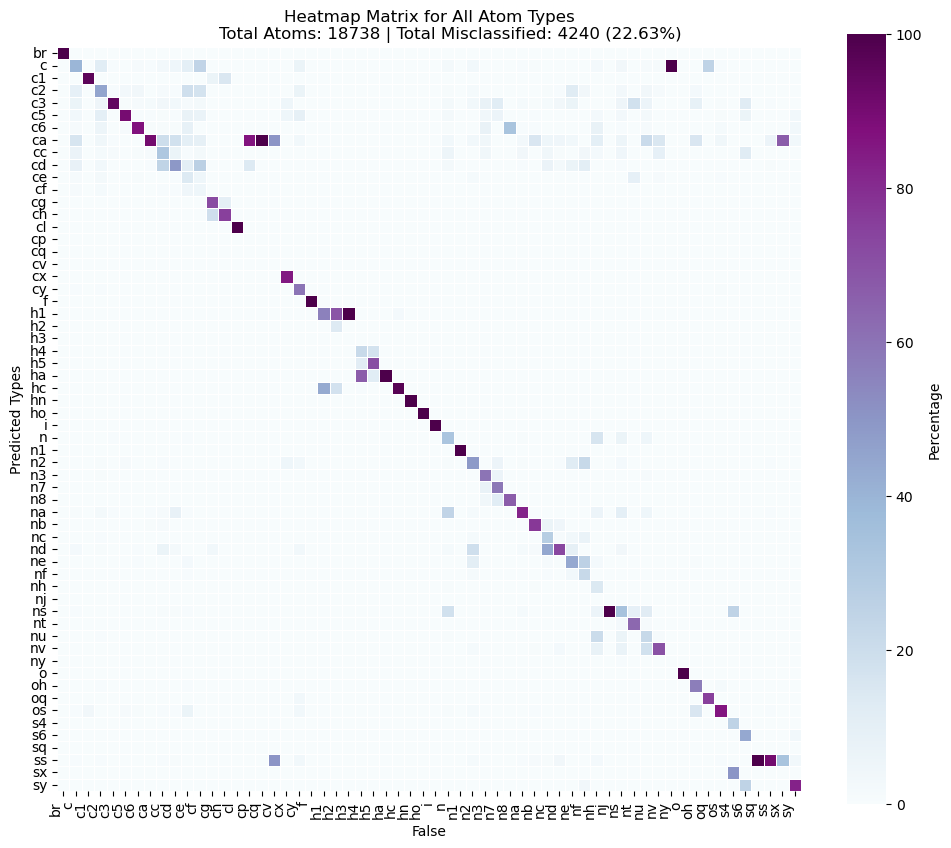

In [3]:
# Initialize BaselineGCN for classification
model = BaselineGCN(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer = GNNTrainer(model, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer.train()
metrics = trainer.evaluate_model(test_dataset)

y_true_labels, y_pred_labels = trainer.predict(test_dataset)

plot_full_heatmap(y_true=y_true_labels, y_pred=y_pred_labels)


# Testing BaselineGAT - 2 layer Graph Convulutions with attention mechanism nn on atom features only with elu activation functions

BaselineGAT - Number of parameters: 1406027


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.5771 | Val Loss: 0.5752
Epoch - 20: Train Loss: 0.5177 | Val Loss: 0.5343
Epoch - 30: Train Loss: 0.4827 | Val Loss: 0.5033


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.4690 | Val Loss: 0.4781
Epoch - 20: Train Loss: 0.4618 | Val Loss: 0.4711
Epoch - 30: Train Loss: 0.4539 | Val Loss: 0.4726


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.4545 | Val Loss: 0.4577
Epoch - 20: Train Loss: 0.4477 | Val Loss: 0.4564
Epoch - 30: Train Loss: 0.4475 | Val Loss: 0.4576


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.4441 | Val Loss: 0.4656
Epoch - 20: Train Loss: 0.4362 | Val Loss: 0.4652
Epoch - 30: Train Loss: 0.4377 | Val Loss: 0.4695


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.4486 | Val Loss: 0.4343
Epoch - 20: Train Loss: 0.4607 | Val Loss: 0.4526
Epoch - 30: Train Loss: 0.4364 | Val Loss: 0.4400


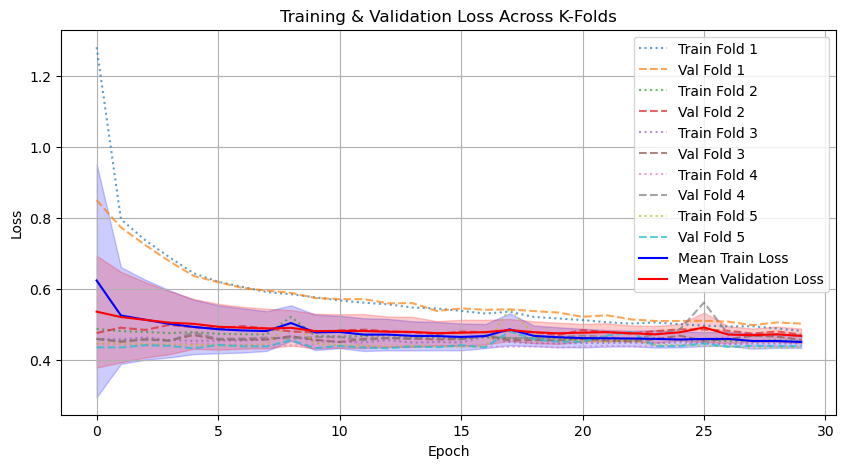

Evaluation Metrics: {'Accuracy': 0.8214323833920376, 'F1-score': 0.8015221948601796}


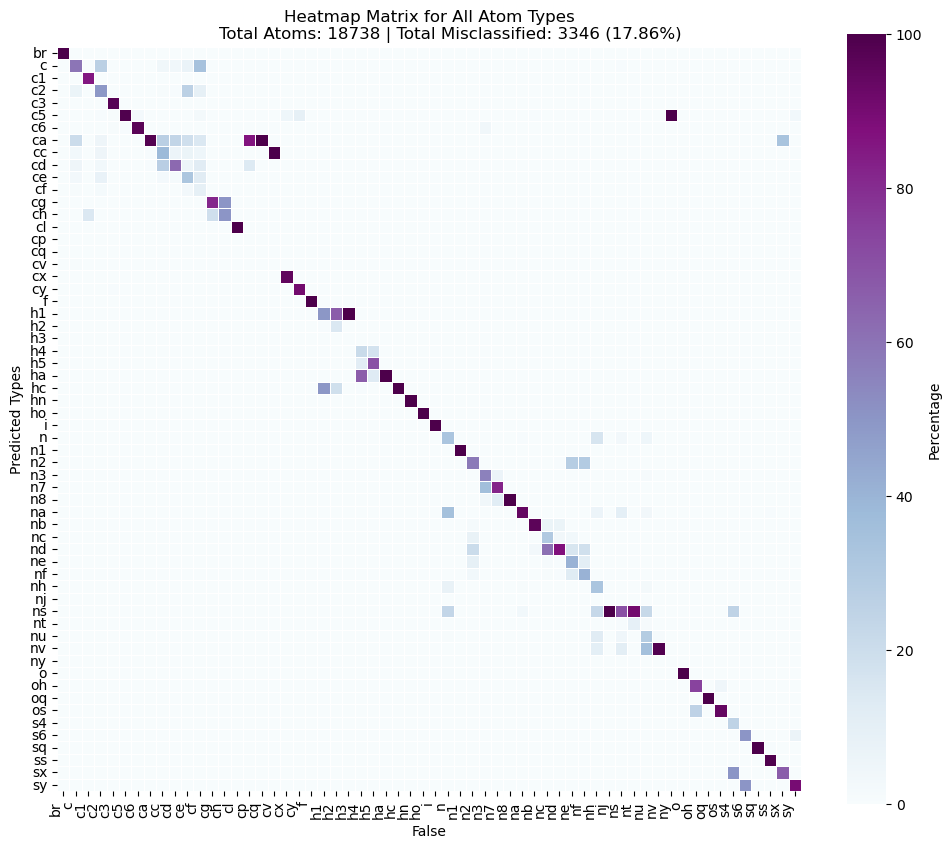

In [4]:
# Initialize baselineGNN for classification
model_GAT = BaselineGAT(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512, heads=4)
trainer_GAT = GNNTrainer(model_GAT, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_GAT.train()
metrics_GAT = trainer_GAT.evaluate_model(test_dataset)

y_true_GAT, y_pred_GAT = trainer_GAT.predict(test_dataset)

plot_full_heatmap(y_true=y_true_GAT, y_pred=y_pred_GAT)


# Testing MPNN_4Layer - 4 layer standard MPNN nn on atom features only with relu activation functions

In [5]:
import importlib
import atoMLtype
importlib.reload(atoMLtype.GNN.GNNmodel)
from atoMLtype.GNN.GNNmodel import MPNN_4L

# Initialize baselineGNN for classification
model_MPNN_4L = MPNN_4L(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer_MPNN_4L = GNNTrainer(model_MPNN_4L, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_MPNN_4L.train()
metrics_MPNN_4L = trainer_MPNN_4L.evaluate_model(test_dataset)

y_true_MPNN_4L, y_pred_MPNN_4L = trainer_MPNN_4L.predict(test_dataset)

plot_full_heatmap(y_true=y_true_MPNN_4L, y_pred=y_pred_MPNN_4L)

ImportError: cannot import name 'MPNN_4L' from 'atoMLtype.GNN.GNNmodel' (/Users/brobello/Capstone_biovia/Biovia-1/atoMLtype/GNN/GNNmodel.py)

# Loading MPNNdataset - Directed Bond Graphs for custom D-MPNN

In [6]:
from atoMLtype.GNN.GNNdataset import MPNNdataset

In [7]:
# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
mpnn_test_dataset = MPNNdataset(sdf_path, json_labels)

[15:55:35] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[15:55:35] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[15:55:35] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[15:55:35] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

FULL DATASET:


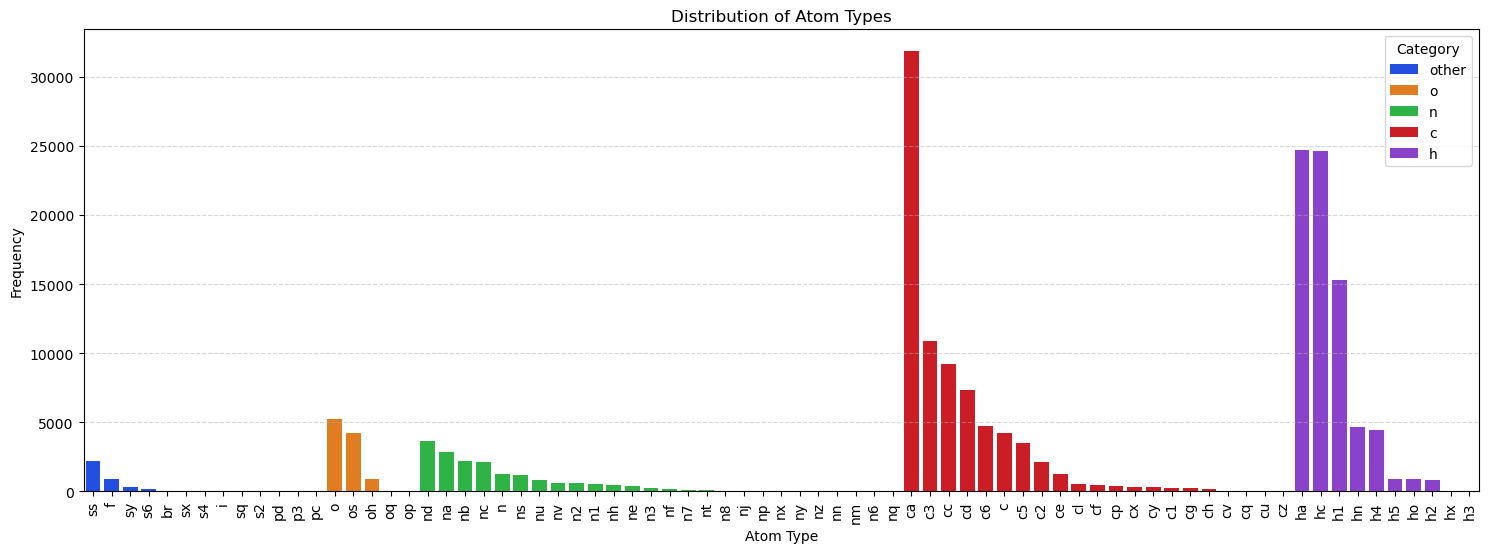

num_atom_features = 154
num_bond_features = 14
num_y_ATs = 75
Total dataset size: 6390
Train split size: 5751
Test split size: 639
First train sample: Data(x=[36, 154], edge_index=[2, 74], edge_attr=[74, 14], y=[36], y_values=[36], mol_name='ZINC00053531')
First test sample: Data(x=[28, 154], edge_index=[2, 58], edge_attr=[58, 14], y=[28], y_values=[28], mol_name='ZINC04661771')


In [8]:
# Initialize dataset
num_atom_feat = mpnn_test_dataset[0].x.shape[1]
num_bond_feat = mpnn_test_dataset[0].edge_attr.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(mpnn_test_dataset))
test_size = len(mpnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(mpnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(mpnn_test_dataset.all_labels))

print(f"num_atom_features = {num_atom_feat}")
print(f"num_bond_features = {num_bond_feat}")
print(f"num_y_ATs = {num_y_ATs}")

print("Total dataset size:", len(mpnn_test_dataset))
print("Train split size:", len(train_dataset))
print("Test split size:", len(test_dataset))

# Check first few samples from each to ensure they aren't empty
print("First train sample:", train_dataset[0])
print("First test sample:", test_dataset[0])

Att_AtomBondMPNN - Number of parameters: 5684816


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.0894 | Val Loss: 0.1063
Epoch - 20: Train Loss: 0.0771 | Val Loss: 0.0935
Epoch - 30: Train Loss: 0.0617 | Val Loss: 0.0950


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.0615 | Val Loss: 0.0701
Epoch - 20: Train Loss: 0.0519 | Val Loss: 0.0701
Epoch - 30: Train Loss: 0.0412 | Val Loss: 0.0923


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.0382 | Val Loss: 0.0684
Epoch - 20: Train Loss: 0.0308 | Val Loss: 0.0756
Epoch - 30: Train Loss: 0.0245 | Val Loss: 0.1024


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.0325 | Val Loss: 0.0482
Epoch - 20: Train Loss: 0.0261 | Val Loss: 0.0746
Epoch - 30: Train Loss: 0.0251 | Val Loss: 0.0673


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.0235 | Val Loss: 0.0423
Epoch - 20: Train Loss: 0.0169 | Val Loss: 0.0610
Epoch - 30: Train Loss: 0.0151 | Val Loss: 0.0769


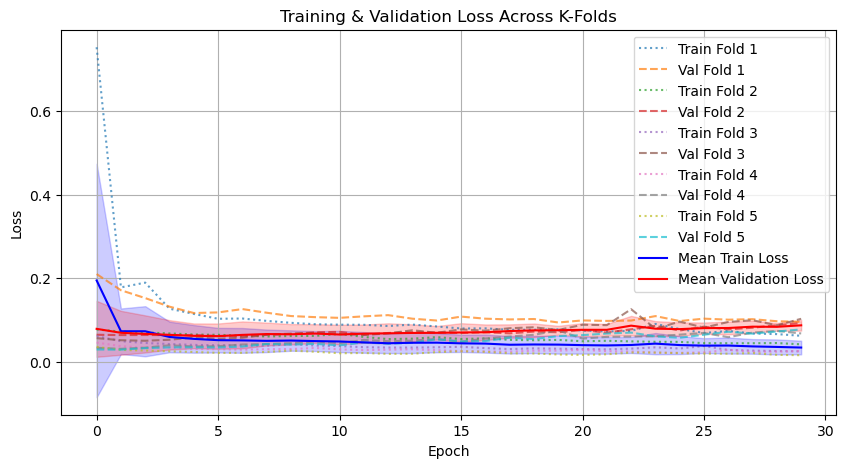

Evaluation Metrics: {'Accuracy': 0.963484776528943, 'F1-score': 0.9632717103411259}


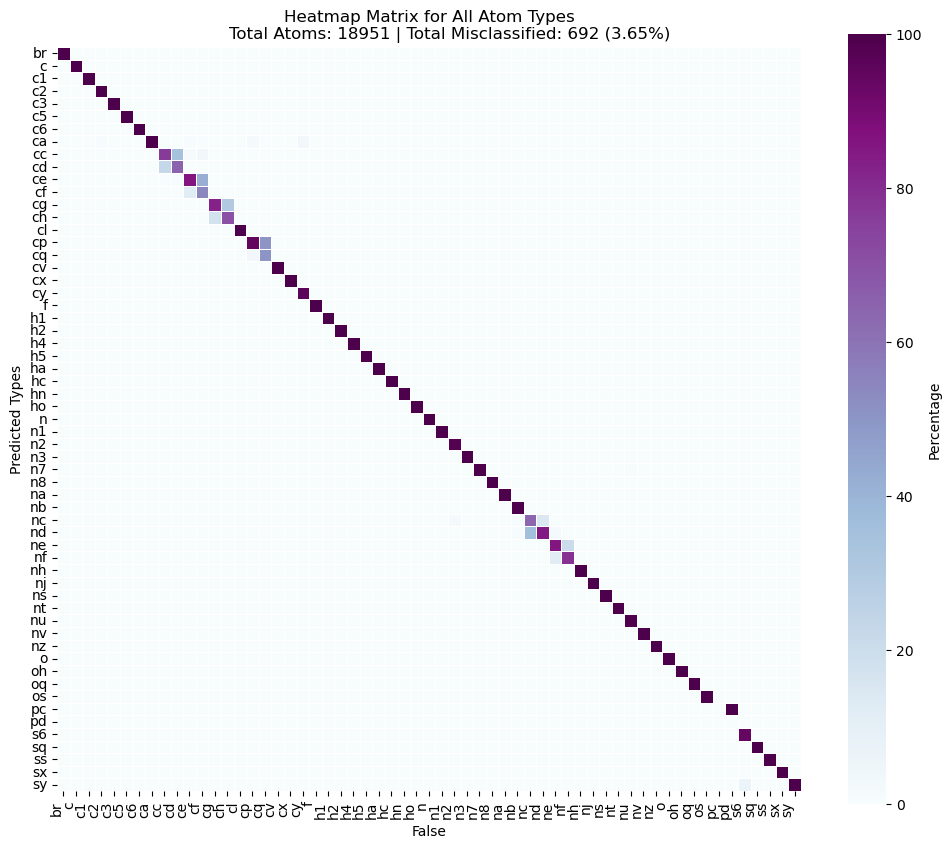

In [9]:
from atoMLtype.GNN.GNNmodel import Att_AtomBondMPNN

model_AtomMPNN = Att_AtomBondMPNN(atom_input_dim=num_atom_feat, bond_input_dim=num_bond_feat, hidden_dim=512, \
                                       num_classes=num_y_ATs, num_layers=5)
trainer_AtomMPNN  = GNNTrainer(model_AtomMPNN , dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_AtomMPNN.train()
metrics_AtomMPNN  = trainer_AtomMPNN .evaluate_model(test_dataset)

y_true_AtomMPNN, y_pred_AtomMPNN  = trainer_AtomMPNN .predict(test_dataset)

plot_full_heatmap(y_true=y_true_AtomMPNN, y_pred=y_pred_AtomMPNN )

In [10]:
from atoMLtype.utils.metrics import plot_full_cross_intra_confusion_matices, plot_category_confusion_matrices

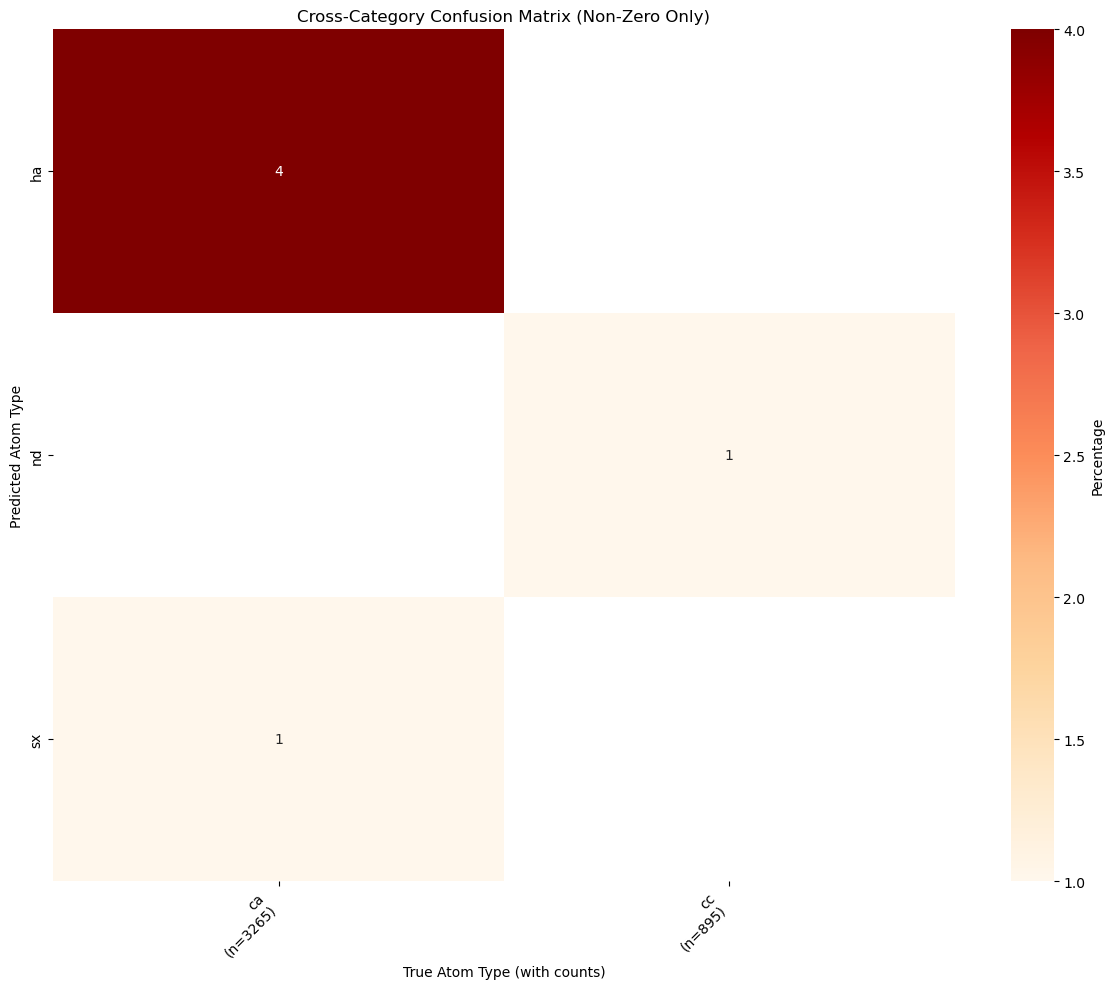

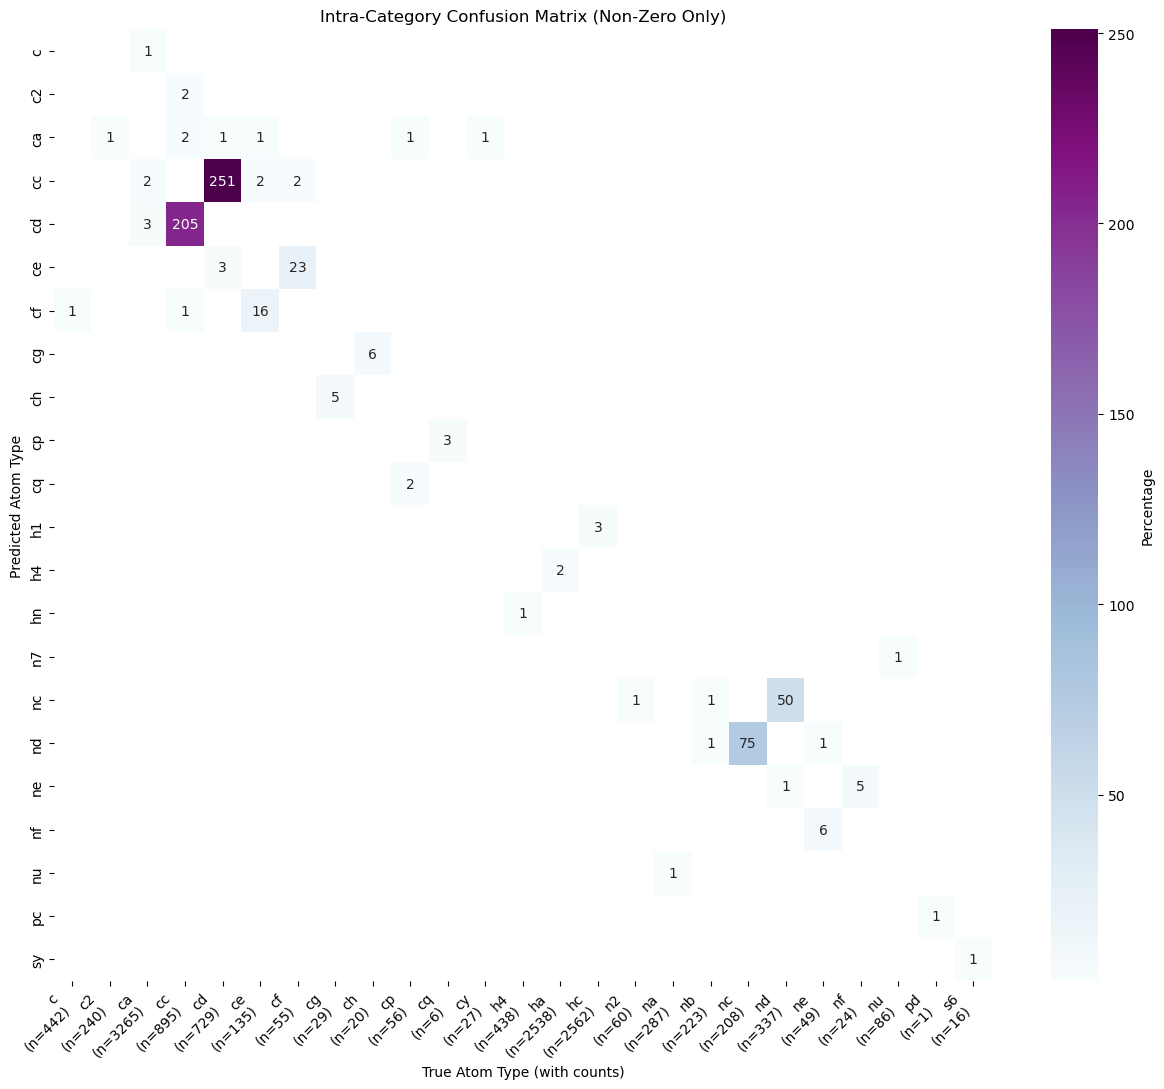

In [11]:
plot_full_cross_intra_confusion_matices(y_true=y_true_AtomMPNN, y_pred=y_pred_AtomMPNN)

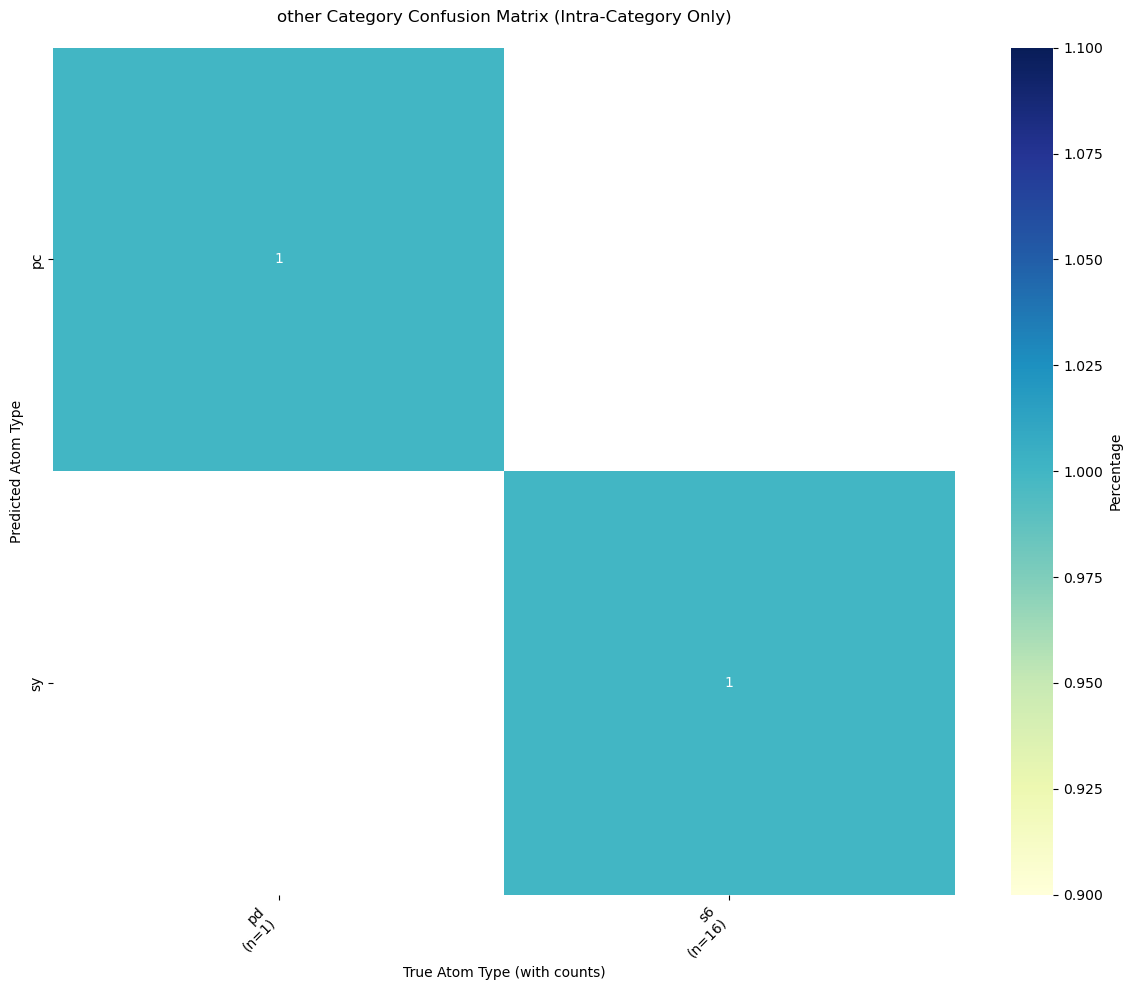

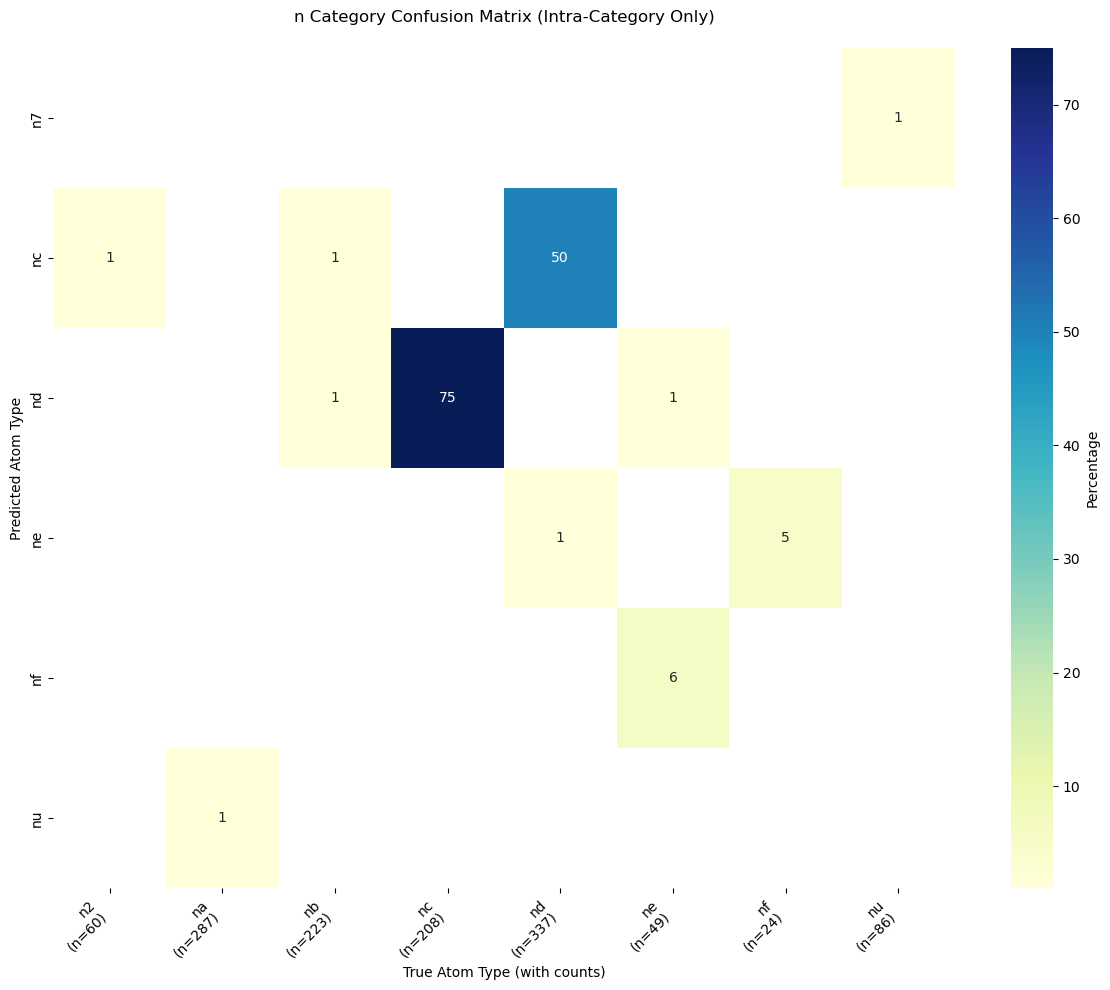

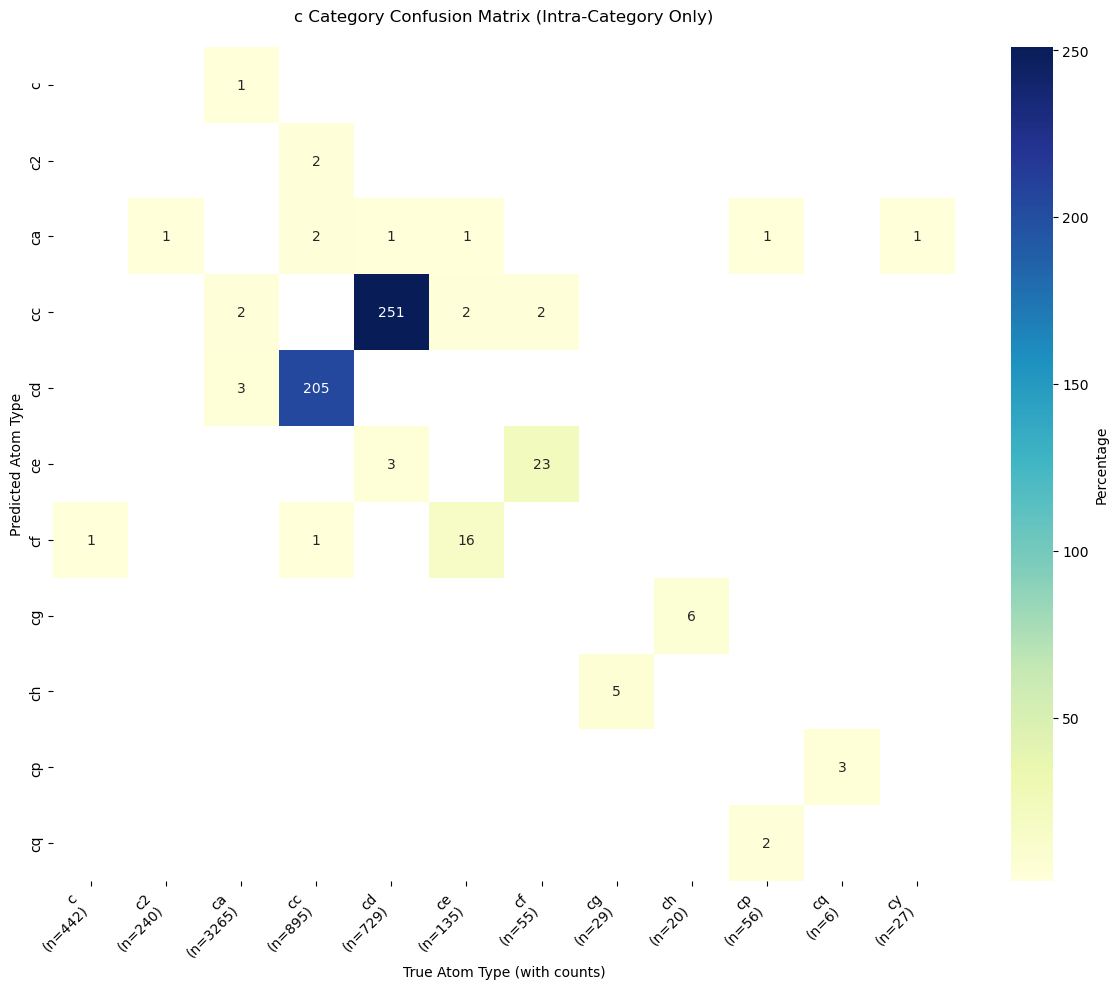

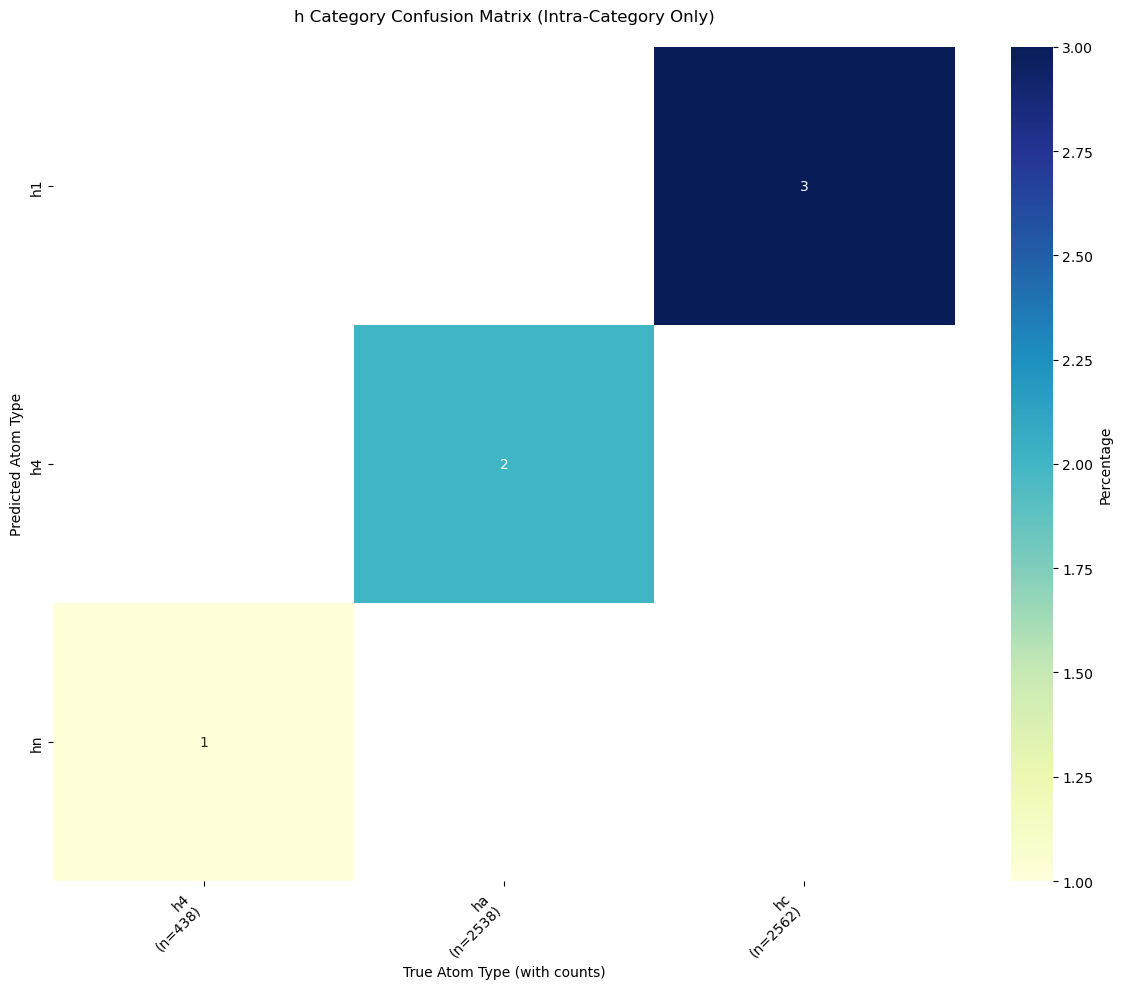

In [12]:
plot_category_confusion_matrices(y_true=y_true_AtomMPNN, y_pred=y_pred_AtomMPNN)